In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [66]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

im = cv.imread("/kaggle/input/datasets/isithadinujaya/cv-images/emma.jpg", cv.IMREAD_GRAYSCALE)

(256,)


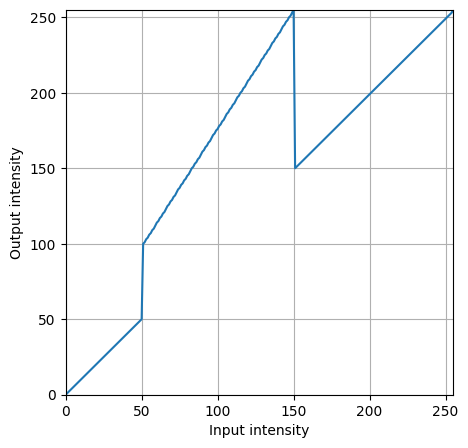

In [67]:
# Define piecewise transformation function
t1 = np.linspace(0, 50, num=51).astype('uint8')
t2 = np.linspace(100, 255, num=100).astype('uint8')
t3 = np.linspace(150, 255, num=105).astype('uint8')

# Concatenate all segments to create the transformation array
t = np.concatenate((t1, t2, t3), axis=0).astype('uint8')
print(t.shape)

# Plot the array
plt.figure(figsize=(5, 5))
plt.plot(t)
plt.xlabel("Input intensity")
plt.xlim(0, 255)
plt.ylim(0, 255)
plt.ylabel("Output intensity")
plt.grid(True)
plt.show()

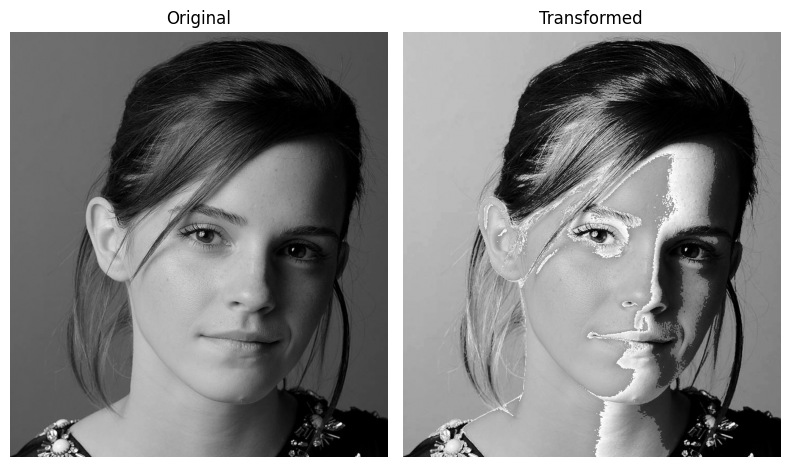

In [68]:
g = t[im]

fig, ax = plt.subplots(1, 2, figsize=(8, 6))
ax[0].imshow(im, cmap='gray', vmin=0, vmax=255)
ax[0].set_title('Original')
ax[0].axis("off")
ax[1].imshow(g, cmap='gray', vmin=0, vmax=255)
ax[1].set_title('Transformed')
ax[1].axis("off")

plt.tight_layout()
plt.show()

# # **Question 2**

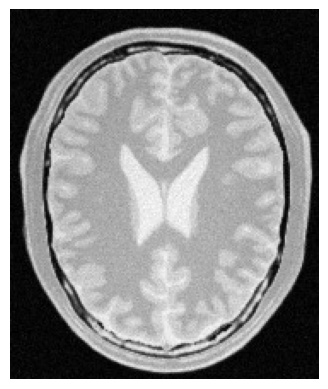

In [69]:

brain = cv.imread("/kaggle/input/datasets/isithadinujaya/vision-data-set/images/q2.jpeg", cv.IMREAD_GRAYSCALE)

plt.imshow(brain, cmap="gray")
plt.axis("off")
plt.show()

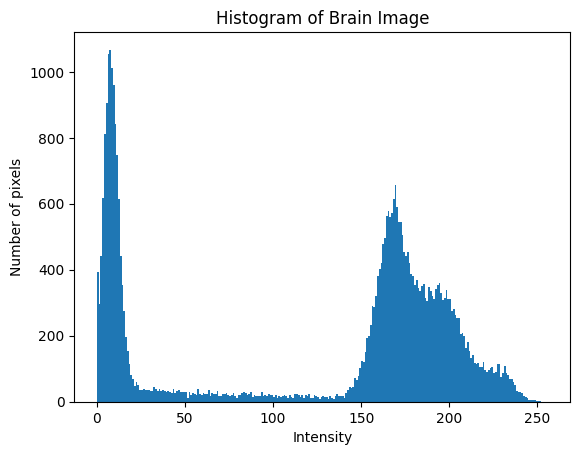

In [70]:
plt.hist(brain.ravel(), bins=256, range=[0, 256])

plt.xlabel("Intensity")
plt.ylabel("Number of pixels")
plt.title("Histogram of Brain Image")
plt.show()

In [71]:
def gaussian_intensity_transform(im, mu, sigma):

    # Possible input intensities: 0 ... 255
    x = np.arange(256, dtype=np.float32)

    # Gaussian intensity transformation
    T = 255 * np.exp(
        -((x - mu) ** 2) / (2 * sigma ** 2)
    )

    # Convert to valid 8-bit values
    T = np.clip(T, 0, 255).astype(np.uint8)

    # Apply transformation using lookup table
    transformed = T[im]

    return transformed, T

mu_white = 150
sigma_white = 20

white_matter, T_white = gaussian_intensity_transform(
    brain,
    mu_white,
    sigma_white
)

mu_gray = 200
sigma_gray = 20

gray_matter, T_gray = gaussian_intensity_transform(
    brain,
    mu_gray,
    sigma_gray
)

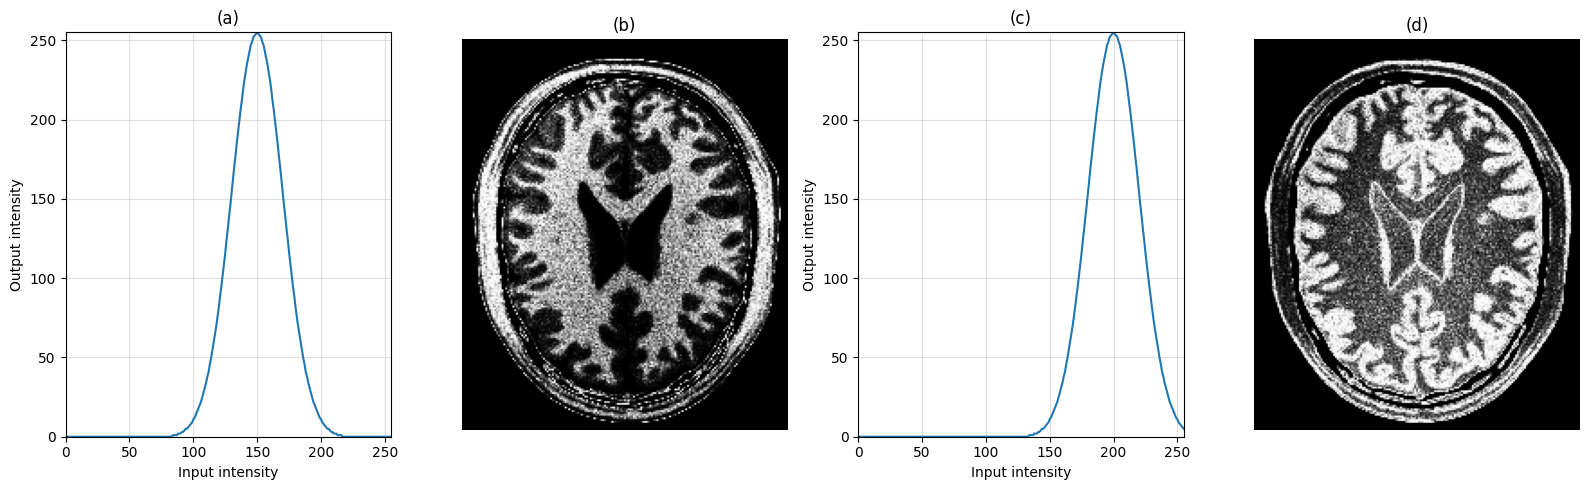

In [72]:
x = np.arange(256)

plt.figure(figsize=(16, 5))


plt.subplot(1, 4, 1)

plt.plot(x, T_white)

plt.xlabel("Input intensity")
plt.ylabel("Output intensity")

plt.xlim(0, 255)
plt.ylim(0, 255)

plt.xticks([0, 50, 100, 150, 200, 250])
plt.yticks([0, 50, 100, 150, 200, 250])

plt.grid(alpha=0.4)

plt.title("(a)")


plt.subplot(1, 4, 2)

plt.imshow(
    white_matter,
    cmap="gray",
    vmin=0,
    vmax=255
)

plt.axis("off")
plt.title("(b)")


plt.subplot(1, 4, 3)

plt.plot(x, T_gray)

plt.xlabel("Input intensity")
plt.ylabel("Output intensity")

plt.xlim(0, 255)
plt.ylim(0, 255)

plt.xticks([0, 50, 100, 150, 200, 250])
plt.yticks([0, 50, 100, 150, 200, 250])

plt.grid(alpha=0.4)

plt.title("(c)")

plt.subplot(1, 4, 4)

plt.imshow(
    gray_matter,
    cmap="gray",
    vmin=0,
    vmax=255
)

plt.axis("off")
plt.title("(d)")


plt.tight_layout()
plt.show()

# #**Question 03**

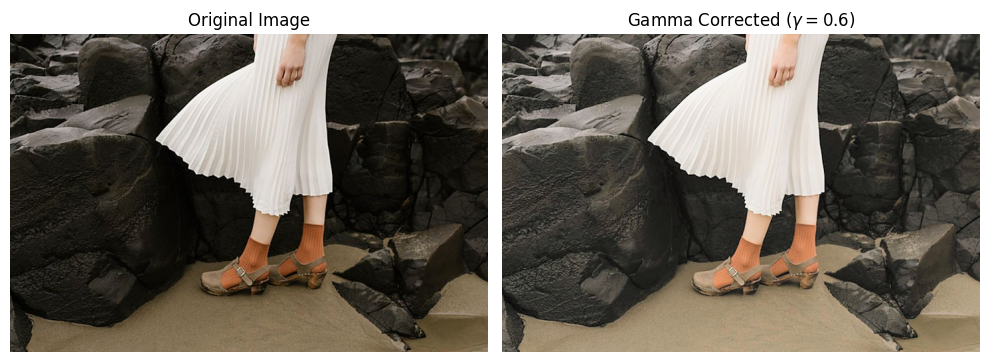

In [73]:


img = cv.imread("/kaggle/input/datasets/isithadinujaya/vision-data-set/images/WhatsApp Image 2026-09-09 at 20.02.44 (1).jpeg")


lab = cv.cvtColor(img, cv.COLOR_BGR2LAB)
L, a, b = cv.split(lab)

gamma = 0.6

L_corrected = 255 * (L / 255.0) ** gamma
L_corrected = L_corrected.astype(np.uint8)
lab_corrected = cv.merge([L_corrected, a, b])
corrected = cv.cvtColor(lab_corrected, cv.COLOR_LAB2BGR)
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
corrected_rgb = cv.cvtColor(corrected, cv.COLOR_BGR2RGB)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(corrected_rgb)
plt.title(f"Gamma Corrected ($\\gamma={gamma}$)")
plt.axis("off")

plt.tight_layout()
plt.show()

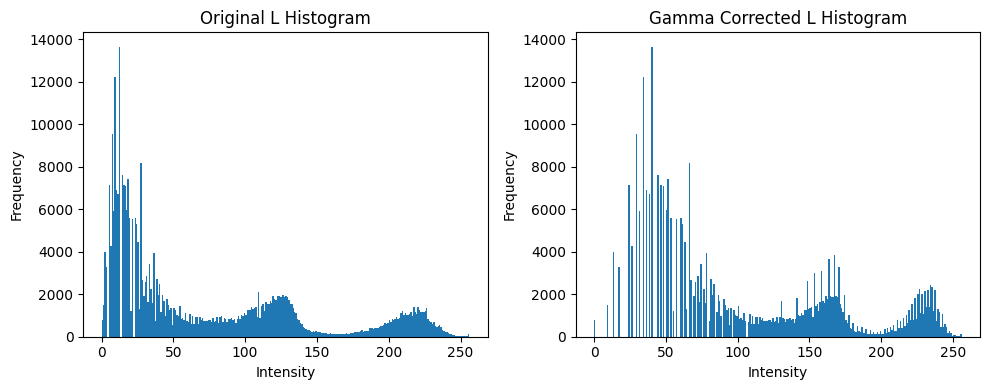

In [74]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(L.ravel(), bins=256, range=[0, 256])
plt.title("Original L Histogram")
plt.xlabel("Intensity")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
plt.hist(L_corrected.ravel(), bins=256, range=[0, 256])
plt.title("Gamma Corrected L Histogram")
plt.xlabel("Intensity")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

## **Question 04**

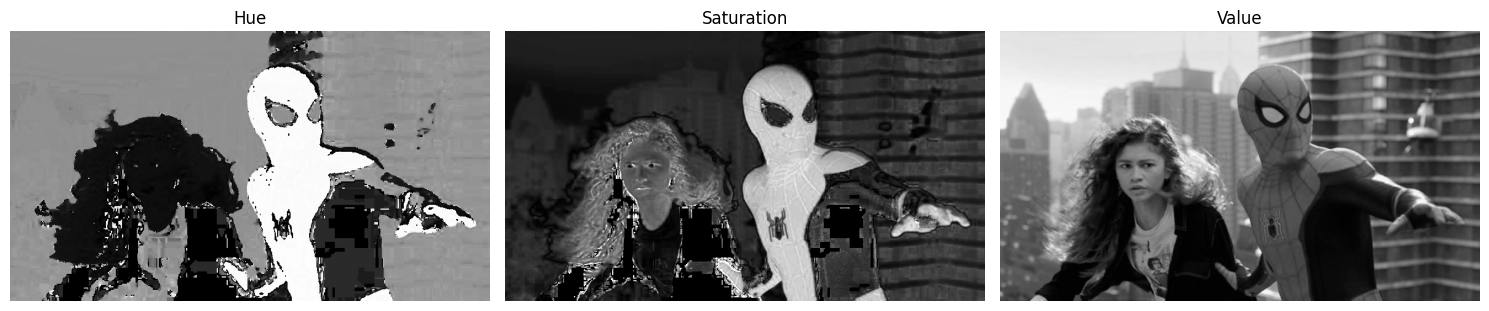

In [75]:


img = cv.imread("/kaggle/input/datasets/isithadinujaya/vision-data-set/images/WhatsApp Image 2026-09-09 at 20.02.441.jpeg")

hsv = cv.cvtColor(img, cv.COLOR_BGR2HSV)

H, S, V = cv.split(hsv)

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(H, cmap="gray")
plt.title("Hue")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(S, cmap="gray")
plt.title("Saturation")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(V, cmap="gray")
plt.title("Value")
plt.axis("off")

plt.tight_layout()
plt.show()

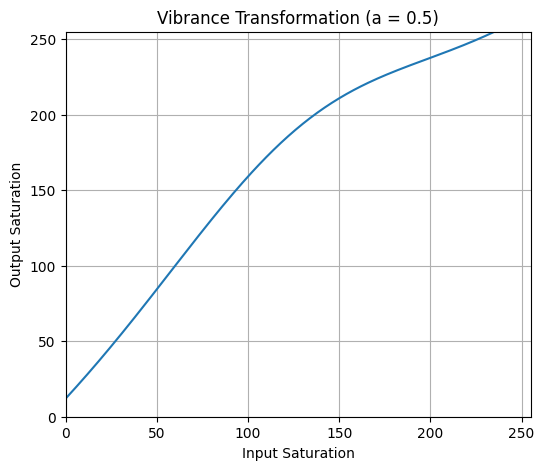

In [76]:
def vibrance_transform(x, a, sigma=70):
    x = x.astype(np.float32)

    y = x + a * 128 * np.exp(
        -((x - 128) ** 2) / (2 * sigma ** 2)
    )

    return np.minimum(y, 255).astype(np.uint8)

a = 0.5
S_new = vibrance_transform(S, a)

hsv_new = cv.merge([H, S_new, V])
enhanced = cv.cvtColor(hsv_new, cv.COLOR_HSV2BGR)

original_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
enhanced_rgb = cv.cvtColor(enhanced, cv.COLOR_BGR2RGB)

x = np.arange(256)

a = 0.5
sigma = 70

y = x + a * 128 * np.exp(
    -((x - 128) ** 2) / (2 * sigma ** 2)
)

y = np.minimum(y, 255)

plt.figure(figsize=(6, 5))
plt.plot(x, y)

plt.xlabel("Input Saturation")
plt.ylabel("Output Saturation")
plt.title(f"Vibrance Transformation (a = {a})")
plt.xlim(0, 255)
plt.ylim(0, 255)
plt.grid()

plt.show()

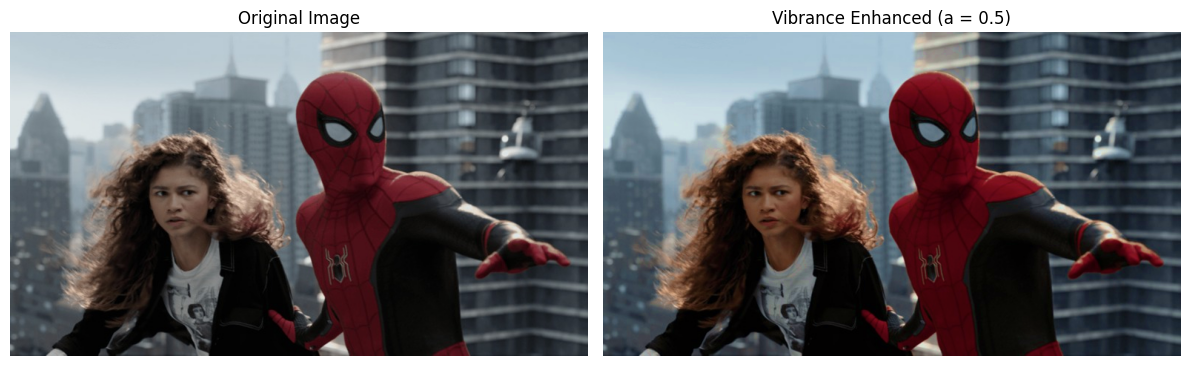

In [77]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(original_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(enhanced_rgb)
plt.title(f"Vibrance Enhanced (a = {a})")
plt.axis("off")

plt.tight_layout()
plt.show()

# # **Question 5**

In [78]:

img = cv.imread("/kaggle/input/datasets/isithadinujaya/vision-data-set/images/shells.tif", cv.IMREAD_GRAYSCALE)

[ WARN:0@6281.247] global grfmt_tiff.cpp:122 TIFF_Warning TIFFFetchNormalTag: ASCII value for tag "ImageDescription" does not end in null byte. Forcing it to be null


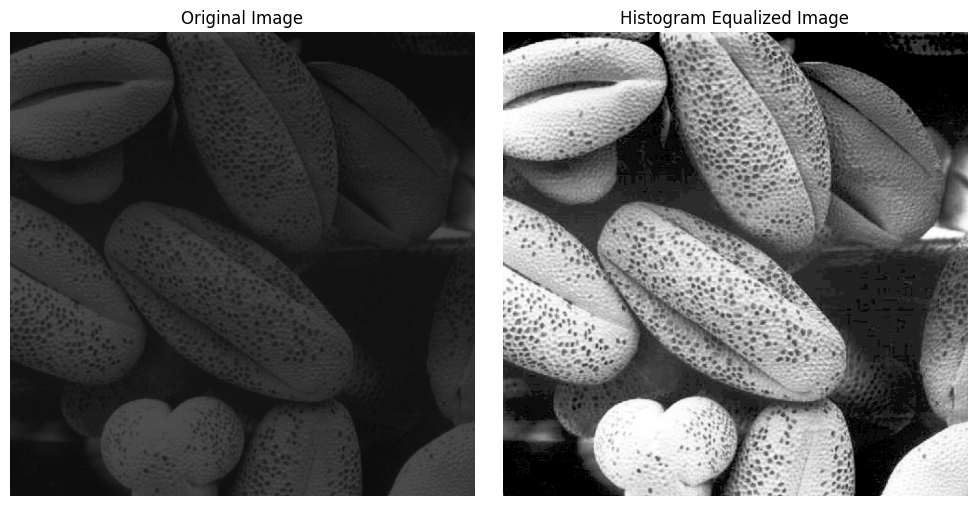

In [79]:
def histogram_equalization(img):

    # Calculate histogram
    hist = np.bincount(img.ravel(), minlength=256)

    # Calculate cumulative histogram
    cdf = np.cumsum(hist)

    # Find the first non-zero CDF value
    cdf_min = cdf[cdf > 0][0]

    # Total number of pixels
    N = img.size

    # Create transformation
    T = np.round(
        255 * (cdf - cdf_min) / (N - cdf_min)
    )

    # Keep values within 0-255
    T = np.clip(T, 0, 255).astype(np.uint8)

    # Apply transformation to every pixel
    equalized = T[img]

    return equalized

equalized = histogram_equalization(img)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap="gray", vmin=0, vmax=255)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(equalized, cmap="gray", vmin=0, vmax=255)
plt.title("Histogram Equalized Image")
plt.axis("off")

plt.tight_layout()
plt.show()

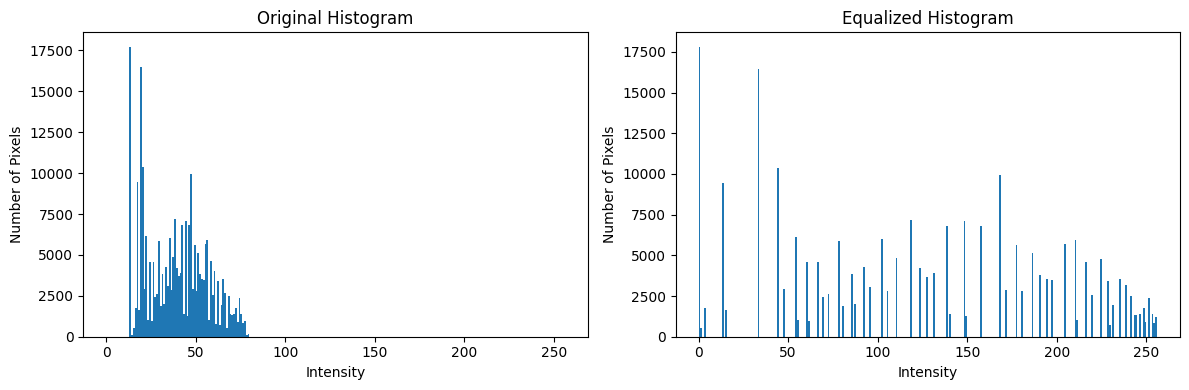

In [80]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(img.ravel(), bins=256, range=[0, 256])
plt.title("Original Histogram")
plt.xlabel("Intensity")
plt.ylabel("Number of Pixels")

plt.subplot(1, 2, 2)
plt.hist(equalized.ravel(), bins=256, range=[0, 256])
plt.title("Equalized Histogram")
plt.xlabel("Intensity")
plt.ylabel("Number of Pixels")

plt.tight_layout()
plt.show()

# # **Question 06**

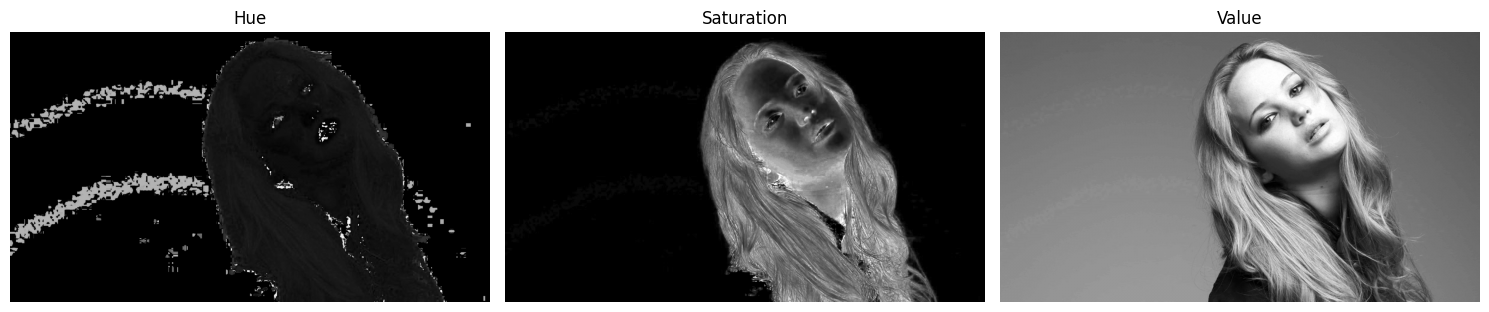

In [81]:
img = cv.imread("/kaggle/input/datasets/isithadinujaya/vision-data-set/images/WhatsApp Image 2026-09-09 at 20.02.44 (2).jpeg")

hsv = cv.cvtColor(img, cv.COLOR_BGR2HSV)

H, S, V = cv.split(hsv)

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(H, cmap="gray")
plt.title("Hue")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(S, cmap="gray")
plt.title("Saturation")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(V, cmap="gray")
plt.title("Value")
plt.axis("off")

plt.tight_layout()
plt.show()

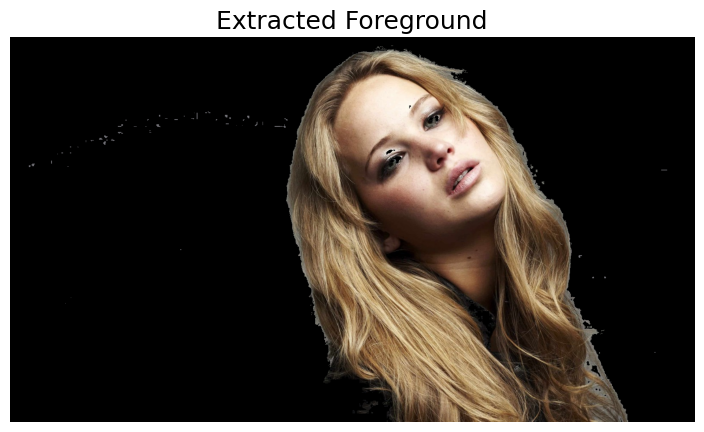

In [82]:

_, mask = cv.threshold(S, 12, 255, cv.THRESH_BINARY)
foreground = cv.bitwise_and(img, img, mask=mask)
plt.figure(figsize=(10, 5))

plt.imshow(cv.cvtColor(foreground, cv.COLOR_BGR2RGB))
plt.title('Extracted Foreground', fontsize=18)
plt.axis('off')
plt.show()

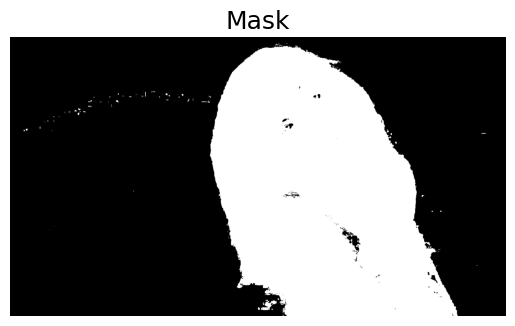

In [83]:
plt.imshow(mask, cmap='gray')
plt.title('Mask', fontsize=18)
plt.axis('off')
plt.show()

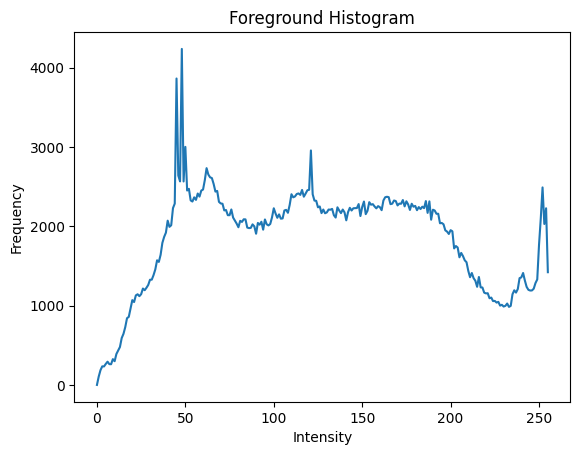

In [84]:
foreground_pixels = V[mask > 0]

hist = np.bincount(
    foreground_pixels.ravel(),
    minlength=256
)

plt.plot(hist)
plt.xlabel("Intensity")
plt.ylabel("Frequency")
plt.title("Foreground Histogram")
plt.show()

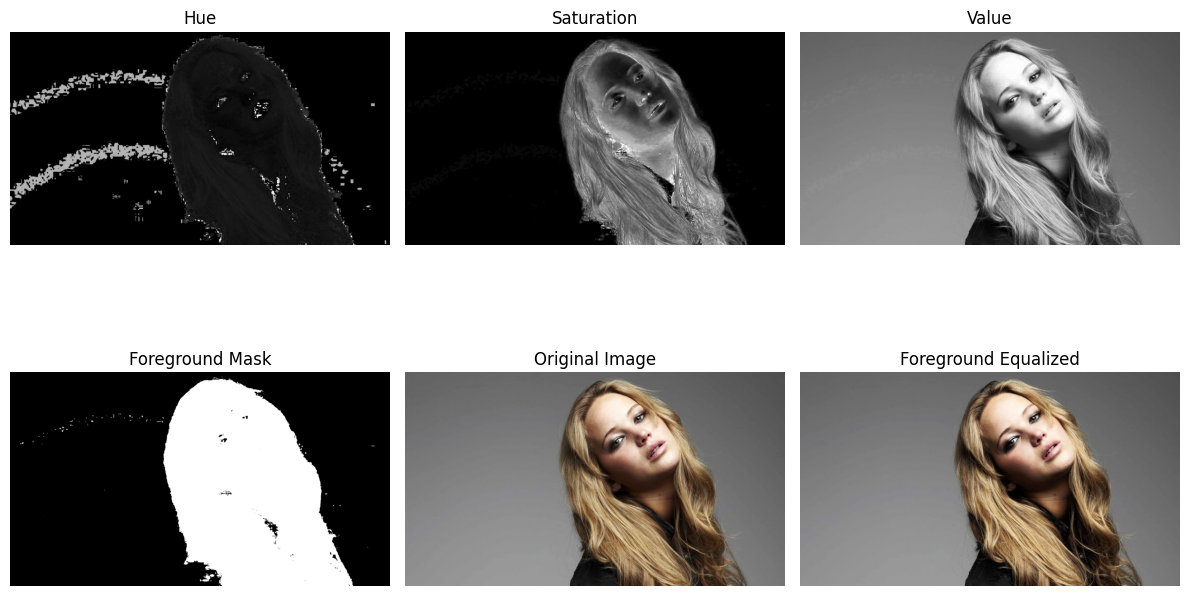

In [85]:
cdf = np.cumsum(hist)
cdf_min = cdf[cdf > 0][0]
N = foreground_pixels.size

T = np.round(
    255 * (cdf - cdf_min) / (N - cdf_min)
)

T = np.clip(T, 0, 255).astype(np.uint8)

V_equalized = V.copy()
V_equalized[mask > 0] = T[V[mask > 0]]

hsv_equalized = cv.merge([H, S, V_equalized])

result = cv.cvtColor(
    hsv_equalized,
    cv.COLOR_HSV2BGR
)

original_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
result_rgb = cv.cvtColor(result, cv.COLOR_BGR2RGB)

plt.figure(figsize=(12, 8))

plt.subplot(2, 3, 1)
plt.imshow(H, cmap="gray")
plt.title("Hue")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(S, cmap="gray")
plt.title("Saturation")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(V, cmap="gray")
plt.title("Value")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(mask, cmap="gray")
plt.title("Foreground Mask")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(original_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(result_rgb)
plt.title("Foreground Equalized")
plt.axis("off")

plt.tight_layout()
plt.show()

# **Question 07**

In [86]:
img = cv.imread("/kaggle/input/datasets/isithadinujaya/vision-data-set/images/WhatsApp Image 2026-09-09 at 20.02.43 (2).jpeg", cv.IMREAD_GRAYSCALE)

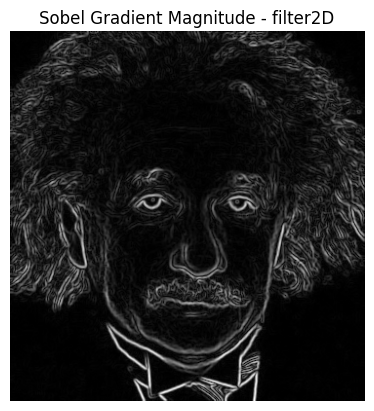

In [87]:
Gx = np.array([
    [1, 0, -1],
    [2, 0, -2],
    [1, 0, -1]
], dtype=np.float32)

Gy = np.array([
    [ 1,  2,  1],
    [ 0,  0,  0],
    [-1, -2, -1]
], dtype=np.float32)

sobel_x = cv.filter2D(img.astype(np.float32), -1, Gx)
sobel_y = cv.filter2D(img.astype(np.float32), -1, Gy)

magnitude = np.sqrt(sobel_x**2 + sobel_y**2)

magnitude_display = cv.normalize(
    magnitude,
    None,
    0,
    255,
    cv.NORM_MINMAX
).astype(np.uint8)

plt.imshow(magnitude_display, cmap="gray")
plt.title("Sobel Gradient Magnitude - filter2D")
plt.axis("off")
plt.show()

In [88]:
def my_filter2d(img, kernel):
    img = img.astype(np.float32)

    kh, kw = kernel.shape

    pad_h = kh // 2
    pad_w = kw // 2

    padded = np.pad(
        img,
        ((pad_h, pad_h), (pad_w, pad_w)),
        mode="constant"
    )

    output = np.zeros_like(img, dtype=np.float32)

    for i in range(img.shape[0]):
        for j in range(img.shape[1]):

            region = padded[
                i:i+kh,
                j:j+kw
            ]

            output[i, j] = np.sum(region * kernel)

    return output

my_sobel_x = my_filter2d(img, Gx)
my_sobel_y = my_filter2d(img, Gy)

my_magnitude = np.sqrt(
    my_sobel_x**2 + my_sobel_y**2
)

my_magnitude_display = cv.normalize(
    my_magnitude,
    None,
    0,
    255,
    cv.NORM_MINMAX
).astype(np.uint8)

my_magnitude_display = cv.normalize(
    my_magnitude,
    None,
    0,
    255,
    cv.NORM_MINMAX
).astype(np.uint8)


smooth_col = np.array([
    [1],
    [2],
    [1]
], dtype=np.float32)

diff_row = np.array([
    [1, 0, -1]
], dtype=np.float32)

temp_x = cv.filter2D(
    img.astype(np.float32),
    -1,
    smooth_col
)

sep_sobel_x = cv.filter2D(
    temp_x,
    -1,
    diff_row
)

smooth_row = np.array([
    [1, 2, 1]
], dtype=np.float32)

diff_col = np.array([
    [ 1],
    [ 0],
    [-1]
], dtype=np.float32)

temp_y = cv.filter2D(
    img.astype(np.float32),
    -1,
    smooth_row
)

sep_sobel_y = cv.filter2D(
    temp_y,
    -1,
    diff_col
)


sep_magnitude = np.sqrt(
    sep_sobel_x**2 + sep_sobel_y**2
)

sep_magnitude_display = cv.normalize(
    sep_magnitude,
    None,
    0,
    255,
    cv.NORM_MINMAX
).astype(np.uint8)

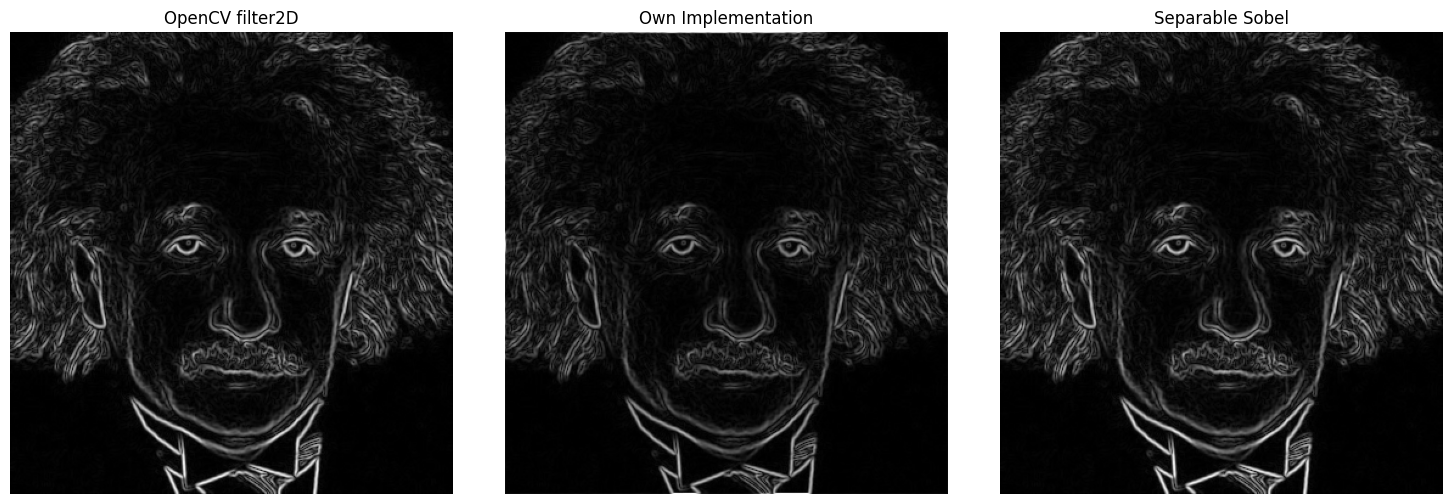

In [89]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(magnitude_display, cmap="gray")
plt.title("OpenCV filter2D")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(my_magnitude_display, cmap="gray")
plt.title("Own Implementation")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(sep_magnitude_display, cmap="gray")
plt.title("Separable Sobel")
plt.axis("off")

plt.tight_layout()
plt.show()

# # **Question 08**

In [90]:

def zoom_nearest(img, scale):
    h, w = img.shape[:2]

    new_h = int(h * scale)
    new_w = int(w * scale)

    if img.ndim == 2:
        output = np.zeros((new_h, new_w), dtype=img.dtype)
    else:
        output = np.zeros((new_h, new_w, img.shape[2]), dtype=img.dtype)

    for i in range(new_h):
        for j in range(new_w):

            src_i = int(round(i / scale))
            src_j = int(round(j / scale))

            src_i = min(src_i, h - 1)
            src_j = min(src_j, w - 1)

            output[i, j] = img[src_i, src_j]

    return output

In [91]:
def zoom_bilinear(img, scale):
    h, w = img.shape[:2]

    new_h = int(h * scale)
    new_w = int(w * scale)

    if img.ndim == 2:
        output = np.zeros((new_h, new_w), dtype=np.float32)
    else:
        output = np.zeros(
            (new_h, new_w, img.shape[2]),
            dtype=np.float32
        )

    img_float = img.astype(np.float32)

    for i in range(new_h):
        for j in range(new_w):

            x = i / scale
            y = j / scale

            x0 = int(np.floor(x))
            y0 = int(np.floor(y))

            x1 = min(x0 + 1, h - 1)
            y1 = min(y0 + 1, w - 1)

            x0 = min(x0, h - 1)
            y0 = min(y0, w - 1)

            dx = x - x0
            dy = y - y0

            Q11 = img_float[x0, y0]
            Q12 = img_float[x0, y1]
            Q21 = img_float[x1, y0]
            Q22 = img_float[x1, y1]

            output[i, j] = (
                (1 - dx) * (1 - dy) * Q11
                + (1 - dx) * dy * Q12
                + dx * (1 - dy) * Q21
                + dx * dy * Q22
            )

    return np.clip(output, 0, 255).astype(np.uint8)

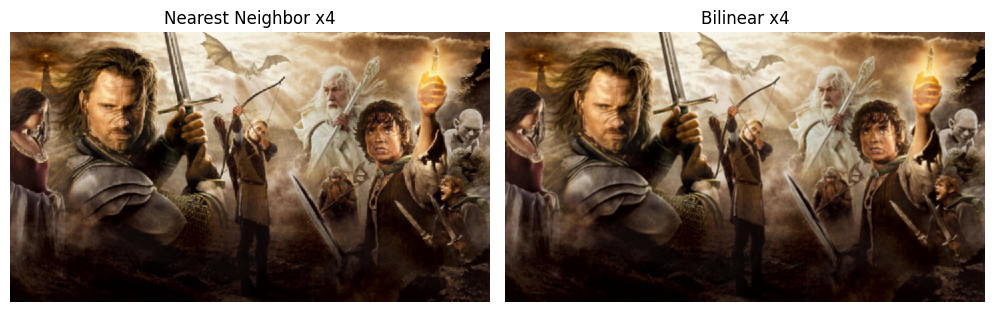

In [92]:
def zoom_image(img, scale, method="nearest"):

    if scale <= 0 or scale > 10:
        raise ValueError("Scale must be in the range (0, 10].")

    if method == "nearest":
        return zoom_nearest(img, scale)

    elif method == "bilinear":
        return zoom_bilinear(img, scale)

    else:
        raise ValueError("Method must be 'nearest' or 'bilinear'.")

img = cv.imread("/kaggle/input/datasets/isithadinujaya/vision-data-set/images/im01small.png")
nearest = zoom_image(img, 4, method="nearest")
bilinear = zoom_image(img, 4, method="bilinear")

plt.figure(figsize=(15, 5))


plt.subplot(1, 3, 2)
plt.imshow(cv.cvtColor(nearest, cv.COLOR_BGR2RGB))
plt.title("Nearest Neighbor x4")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(cv.cvtColor(bilinear, cv.COLOR_BGR2RGB))
plt.title("Bilinear x4")
plt.axis("off")

plt.tight_layout()
plt.show()

In [93]:
def normalized_ssd(reference, test):
    reference = reference.astype(np.float64)
    test = test.astype(np.float64)

    numerator = np.sum((reference - test) ** 2)
    denominator = np.sum(reference ** 2)

    return numerator / denominator

original_large = cv.imread("/kaggle/input/datasets/isithadinujaya/vision-data-set/images/im01.png")
small = cv.imread("/kaggle/input/datasets/isithadinujaya/vision-data-set/images/im01small.png")


nearest_4x = zoom_image(small, 4, "nearest")
bilinear_4x = zoom_image(small, 4, "bilinear")

ssd_nearest = normalized_ssd(
    original_large,
    nearest_4x
)

ssd_bilinear = normalized_ssd(
    original_large,
    bilinear_4x
)

print("Nearest Neighbor NSSD :", ssd_nearest)
print("Bilinear NSSD         :", ssd_bilinear)

Nearest Neighbor NSSD : 0.022590177565118504
Bilinear NSSD         : 0.017718956455122437


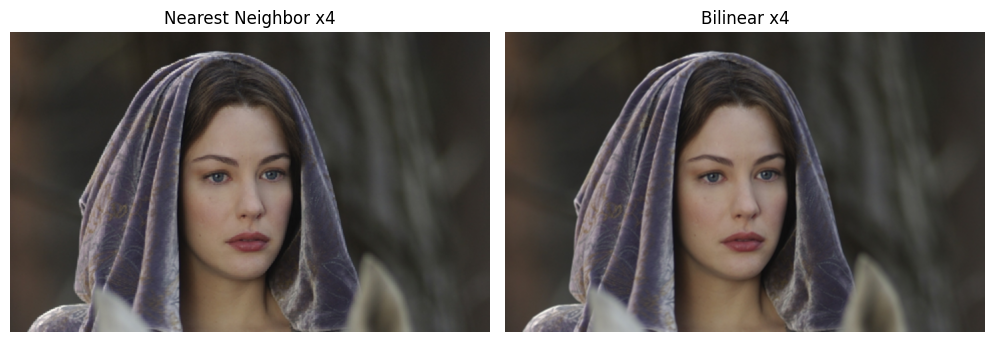

In [94]:
img = cv.imread("/kaggle/input/datasets/isithadinujaya/vision-data-set/images/im02small.png")
nearest = zoom_image(img, 4, method="nearest")
bilinear = zoom_image(img, 4, method="bilinear")

plt.figure(figsize=(15, 5))


plt.subplot(1, 3, 2)
plt.imshow(cv.cvtColor(nearest, cv.COLOR_BGR2RGB))
plt.title("Nearest Neighbor x4")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(cv.cvtColor(bilinear, cv.COLOR_BGR2RGB))
plt.title("Bilinear x4")
plt.axis("off")

plt.tight_layout()
plt.show()

In [95]:
original_large = cv.imread("/kaggle/input/datasets/isithadinujaya/vision-data-set/images/im02.png")
small = cv.imread("/kaggle/input/datasets/isithadinujaya/vision-data-set/images/im02small.png")


nearest_4x = zoom_image(small, 4, "nearest")
bilinear_4x = zoom_image(small, 4, "bilinear")

ssd_nearest = normalized_ssd(
    original_large,
    nearest_4x
)

ssd_bilinear = normalized_ssd(
    original_large,
    bilinear_4x
)

print("Nearest Neighbor NSSD :", ssd_nearest)
print("Bilinear NSSD         :", ssd_bilinear)

Nearest Neighbor NSSD : 0.01023969256323595
Bilinear NSSD         : 0.007757186831744027


# # **Question 09**

In [96]:


img = cv.imread("/kaggle/input/datasets/isithadinujaya/vision-data-set/images/WhatsApp Image 2026-09-09 at 20.02.43 (1).jpeg")

img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

In [97]:
h, w = img.shape[:2]

rect = (
    10,       # x
    10,       # y
    w - 20,   # width
    h - 20    # height
)

mask = np.zeros(img.shape[:2], np.uint8)

bg_model = np.zeros((1, 65), np.float64)
fg_model = np.zeros((1, 65), np.float64)

cv.grabCut(
    img,
    mask,
    rect,
    bg_model,
    fg_model,
    5,
    cv.GC_INIT_WITH_RECT
)

final_mask = np.where(
    (mask == cv.GC_FGD) |
    (mask == cv.GC_PR_FGD),
    1,
    0
).astype("uint8")

In [98]:
foreground = img * final_mask[:, :, np.newaxis]

In [99]:
background_mask = 1 - final_mask

background = img * background_mask[:, :, np.newaxis]

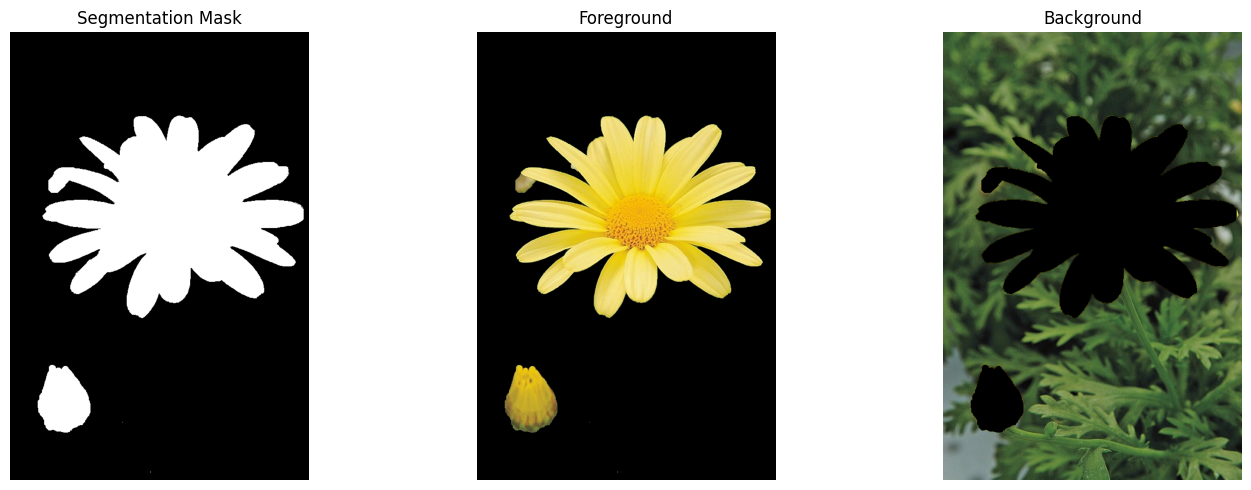

In [101]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(final_mask, cmap="gray")
plt.title("Segmentation Mask")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cv.cvtColor(foreground, cv.COLOR_BGR2RGB))
plt.title("Foreground")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(cv.cvtColor(background, cv.COLOR_BGR2RGB))
plt.title("Background")
plt.axis("off")

plt.tight_layout()
plt.show()

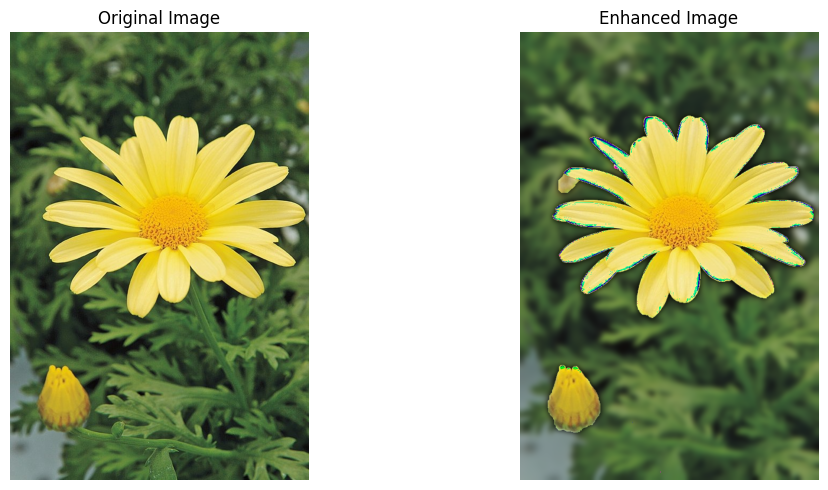

In [102]:
blurred_background = cv.GaussianBlur(
    background,
    (31, 31),
    0
)

enhanced = foreground + blurred_background

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(enhanced, cv.COLOR_BGR2RGB))
plt.title("Enhanced Image")
plt.axis("off")

plt.tight_layout()
plt.show()

# #**Question 10**

In [103]:
img = cv.imread("/kaggle/input/datasets/isithadinujaya/vision-data-set/images/WhatsApp Image 2026-09-09 at 20.02.44 (3).jpeg")

img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

sigma_s = 5  
sigma_r = 30  

radius = 5
d = 2 * radius + 1

print("Kernel diameter =", d)
print("sigma_s =", sigma_s)
print("sigma_r =", sigma_r)

Kernel diameter = 11
sigma_s = 5
sigma_r = 30


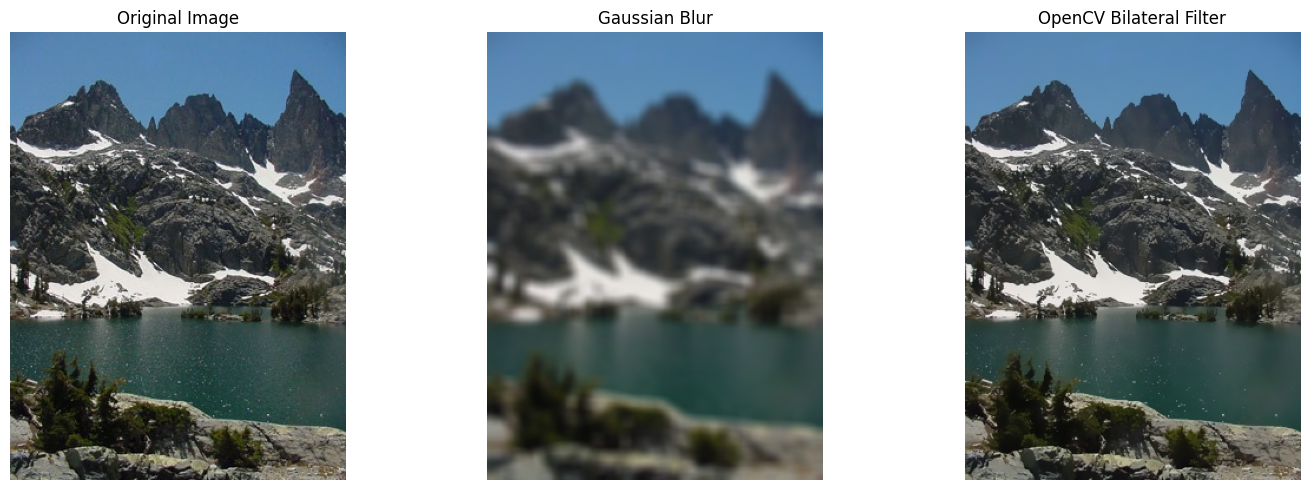

In [104]:
bilateral_cv = cv.bilateralFilter(
    img,
    d=d,
    sigmaColor=sigma_r,
    sigmaSpace=sigma_s
)

gaussian = cv.GaussianBlur(
    img,
    (d, d),
    sigmaX=sigma_s,
    sigmaY=sigma_s
)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cv.cvtColor(gaussian, cv.COLOR_BGR2RGB))
plt.title("Gaussian Blur")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(cv.cvtColor(bilateral_cv, cv.COLOR_BGR2RGB))
plt.title("OpenCV Bilateral Filter")
plt.axis("off")

plt.tight_layout()
plt.show()

In [105]:
def my_bilateral_filter(img, sigma_s, sigma_r, radius):
    
    img_float = img.astype(np.float32)

    h, w, channels = img.shape

    # Reflect padding to handle image boundaries
    padded = cv.copyMakeBorder(
        img_float,
        radius,
        radius,
        radius,
        radius,
        cv.BORDER_REFLECT
    )

    output = np.zeros_like(img_float)

    y, x = np.mgrid[
        -radius:radius+1,
        -radius:radius+1
    ]

    spatial_weights = np.exp(
        -(x**2 + y**2) / (2 * sigma_s**2)
    )

    for i in range(h):
        for j in range(w):

            # Local neighborhood
            region = padded[
                i:i + 2*radius + 1,
                j:j + 2*radius + 1
            ]

            # Center pixel
            center = padded[
                i + radius,
                j + radius
            ]

            color_distance_sq = np.sum(
                (region - center)**2,
                axis=2
            )

            range_weights = np.exp(
                -color_distance_sq /
                (2 * sigma_r**2)
            )

            weights = spatial_weights * range_weights

            weights_sum = np.sum(weights)

            output[i, j] = np.sum(
                region * weights[:, :, np.newaxis],
                axis=(0, 1)
            ) / weights_sum

    return np.clip(output, 0, 255).astype(np.uint8)

bilateral_own = my_bilateral_filter(
    img,
    sigma_s=sigma_s,
    sigma_r=sigma_r,
    radius=radius
)

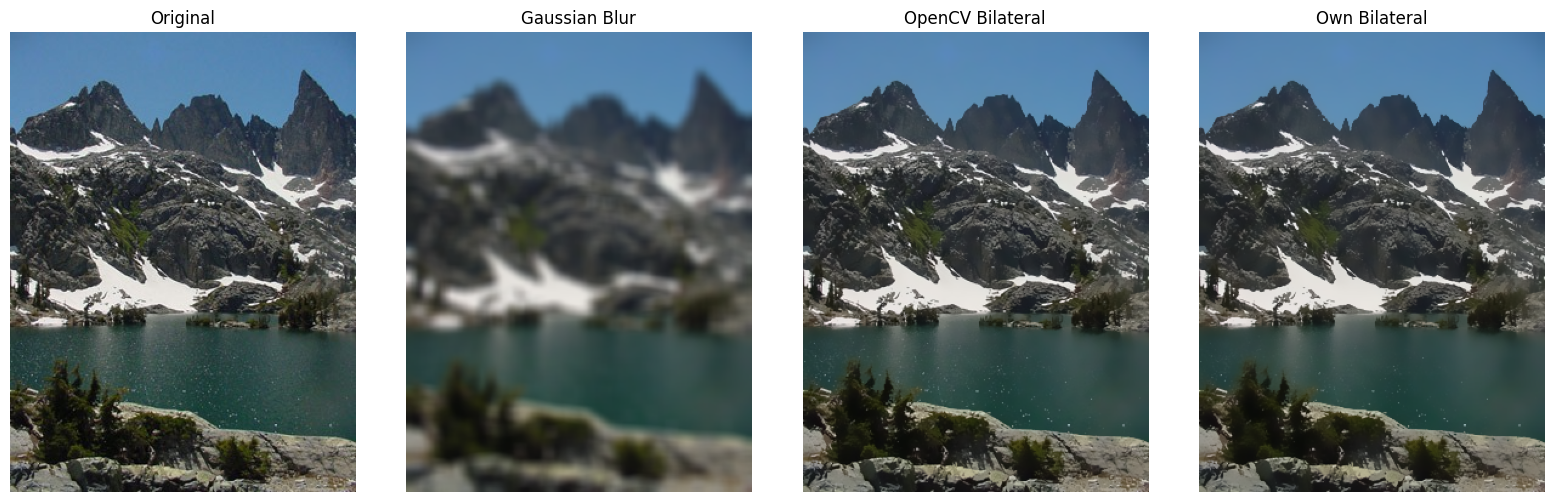

In [106]:
plt.figure(figsize=(16, 5))

plt.subplot(1, 4, 1)
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(cv.cvtColor(gaussian, cv.COLOR_BGR2RGB))
plt.title("Gaussian Blur")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(cv.cvtColor(bilateral_cv, cv.COLOR_BGR2RGB))
plt.title("OpenCV Bilateral")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(cv.cvtColor(bilateral_own, cv.COLOR_BGR2RGB))
plt.title("Own Bilateral")
plt.axis("off")

plt.tight_layout()
plt.show()

In [107]:
def mse(img1, img2):
    img1 = img1.astype(np.float64)
    img2 = img2.astype(np.float64)

    return np.mean((img1 - img2)**2)

mse_value = mse(
    bilateral_cv,
    bilateral_own
)

print("MSE between OpenCV and own bilateral filter:",
      mse_value)


def psnr(img1, img2):

    error = mse(img1, img2)

    if error == 0:
        return float("inf")

    return 10 * np.log10(
        (255.0 ** 2) / error
    )


psnr_value = psnr(
    bilateral_cv,
    bilateral_own
)

print("PSNR between OpenCV and own bilateral filter:",
      psnr_value, "dB")

MSE between OpenCV and own bilateral filter: 8.655109264389043
PSNR between OpenCV and own bilateral filter: 38.75807805973459 dB
